# Homework 14 — CIFAR-10 Classifier

In this homework we build a CNN classifier for the **CIFAR-10** dataset.
The dataset contains **60,000 colour images** (32×32 px) across **10 classes**:
plane, car, bird, cat, deer, dog, frog, horse, ship, truck.

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras import Model
from collections import Counter
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


---
## Step 0 — Dataset Inspection

In [17]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

num_classes = len(classes)
size = x_train.shape[1]

print(f'Train set: {x_train.shape}  labels: {y_train.shape}')
print(f'Test set:  {x_test.shape}  labels: {y_test.shape}')
print(f'Image size: {size}x{size} px, {x_train.shape[3]} channels')

Train set: (50000, 32, 32, 3)  labels: (50000, 1)
Test set:  (10000, 32, 32, 3)  labels: (10000, 1)
Image size: 32x32 px, 3 channels


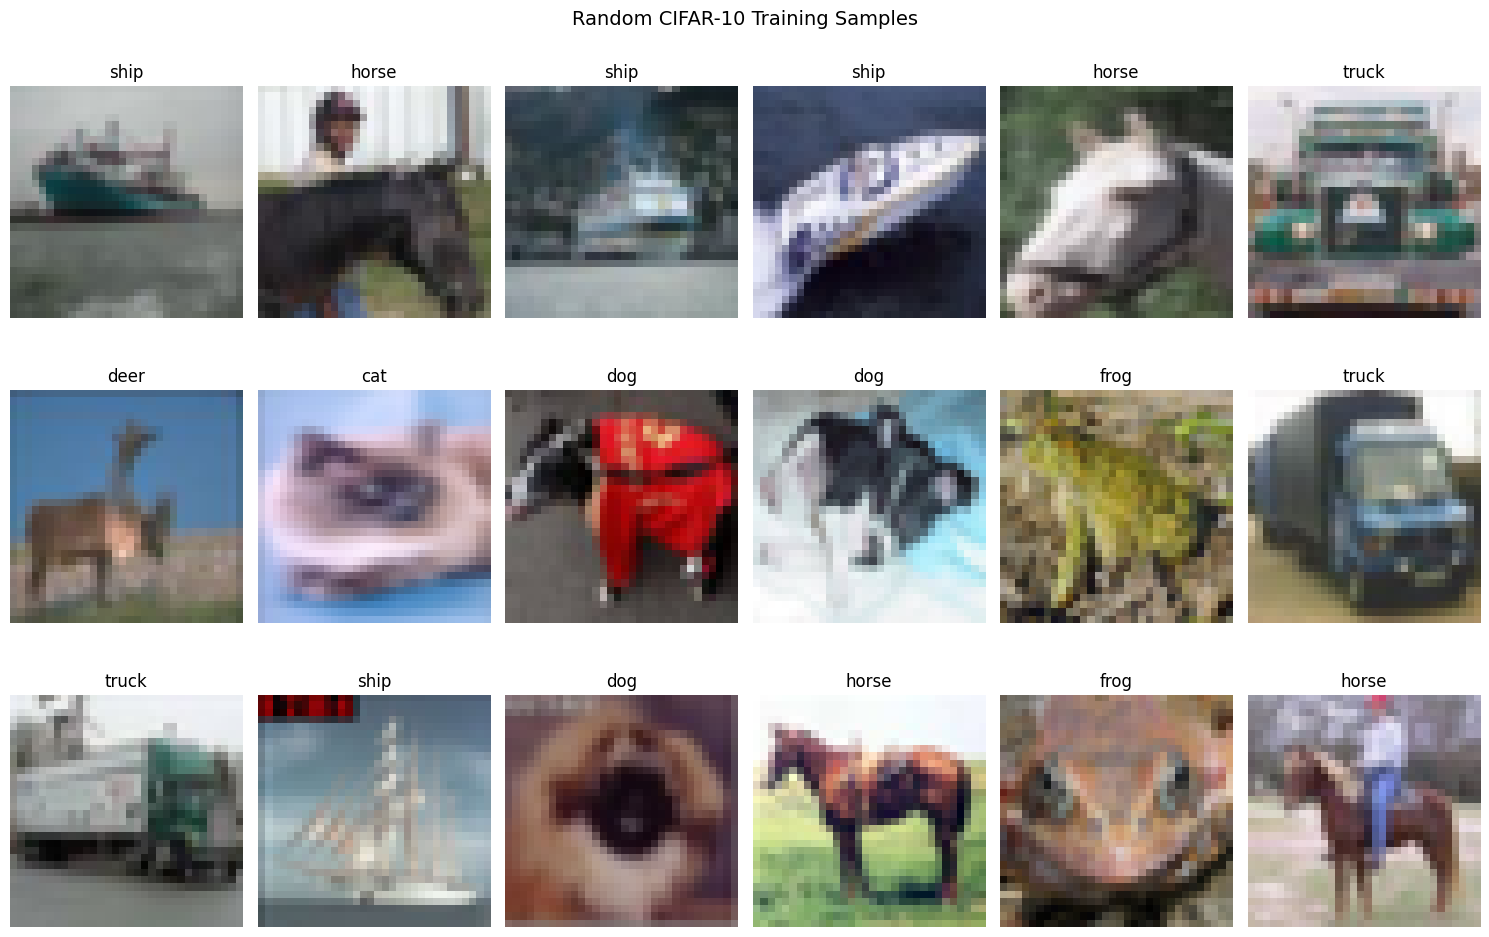

In [19]:
# Visualise 18 random samples (3x6 grid)
for ii in range(18):
    plt.subplot(3, 6, ii + 1)
    idx = np.random.randint(0, len(x_train))
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx].item())])
    plt.axis(False)

plt.suptitle('Random CIFAR-10 Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

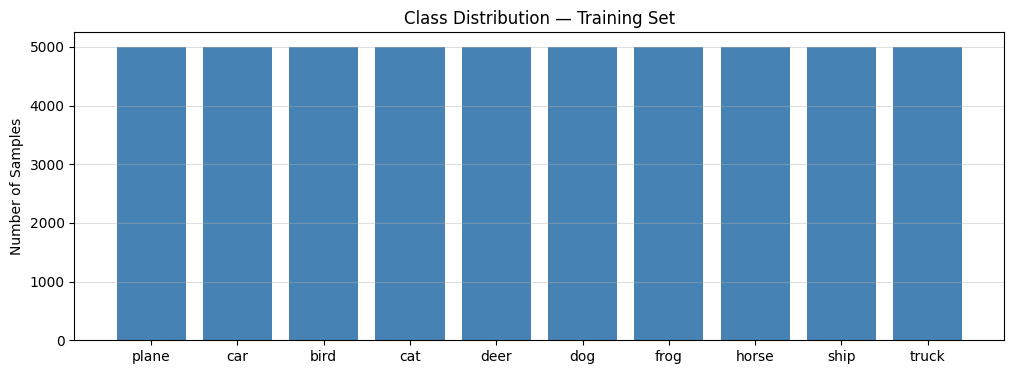

  plane   : 5000 samples
  car     : 5000 samples
  bird    : 5000 samples
  cat     : 5000 samples
  deer    : 5000 samples
  dog     : 5000 samples
  frog    : 5000 samples
  horse   : 5000 samples
  ship    : 5000 samples
  truck   : 5000 samples

Dataset is balanced: True


In [20]:
# Compute class histogram
hist = Counter(y_train.flatten().tolist())

plt.figure(figsize=(12, 4))
plt.bar([classes[k] for k in sorted(hist.keys())],
        [hist[k] for k in sorted(hist.keys())],
        color='steelblue')
plt.title('Class Distribution — Training Set')
plt.ylabel('Number of Samples')
plt.grid(True, axis='y', alpha=0.4)
plt.show()

for k in sorted(hist.keys()):
    print(f'  {classes[k]:8s}: {hist[k]} samples')
print(f'\nDataset is balanced: {max(hist.values()) == min(hist.values())}')

**The CIFAR-10 dataset is perfectly balanced** — each class contains exactly 5,000 training samples (50,000 total / 10 classes). The histogram is completely flat, so no class weighting or oversampling is needed.

---
## Step 1 — Data Preparation

In [21]:
# Normalisation: pixel values from [0, 255] → [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encoding of labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test,  num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test),  'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


---
## Step 2 — Building the Classifier (Baseline CNN)

In [22]:
# Baseline CNN — same architecture as the MNIST lesson
inputs = Input(shape=(size, size, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

---
## Step 3 — Training

In [23]:
epochs     = 25
batch_size = 128

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
t0 = time()
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)
print(f'\nTraining time: {time()-t0:.1f}s')

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4364 - loss: 1.5796 - val_accuracy: 0.5444 - val_loss: 1.3242
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5690 - loss: 1.2245 - val_accuracy: 0.5956 - val_loss: 1.1699
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6185 - loss: 1.0897 - val_accuracy: 0.6284 - val_loss: 1.0698
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6442 - loss: 1.0205 - val_accuracy: 0.6384 - val_loss: 1.0512
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6531 - loss: 1.0124 - val_accuracy: 0.6370 - val_loss: 1.0884
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6467 - loss: 1.0696 - val_accuracy: 0.6278 - val_loss: 1.1857
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6125 - loss: 1.3161 - val_accuracy: 0.5664 - val_loss: 1.8683
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5776 - loss: 1.9049 - val_accu

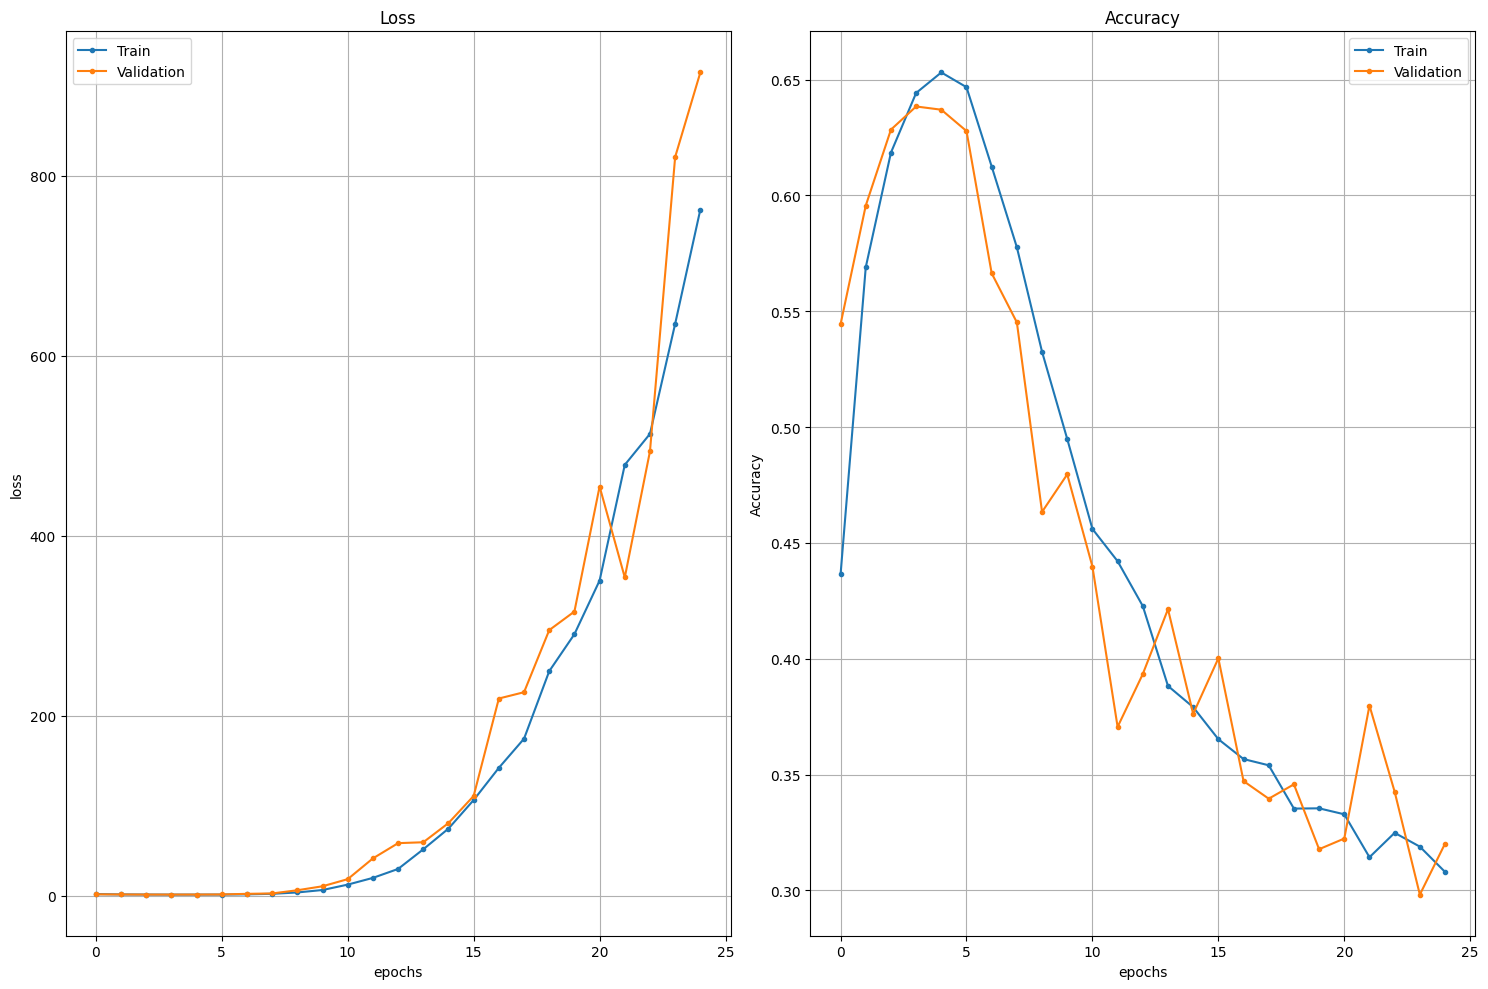

Train Acc      0.30799999833106995
Validation Acc 0.32019999623298645


In [24]:
# Plot training history
h = history.history
epochs_range = range(len(h['loss']))

plt.subplot(121)
plt.plot(epochs_range, h['loss'], '.-', epochs_range, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.title('Loss')

plt.subplot(122)
plt.plot(epochs_range, h['accuracy'], '.-', epochs_range, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')

plt.tight_layout()
plt.show()

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

---
## Step 4 — Evaluation

In [25]:
# Compute sparse (integer) labels and predictions
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

In [26]:
# Per-class accuracy
print('Per-class accuracy:')
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc  = np.mean(y_pred[mask] == y_true[mask])
    print(f'  {class_name:8s}: {acc:.4f}')

Per-class accuracy:
  plane   : 0.3410
  car     : 0.2240
  bird    : 0.0250
  cat     : 0.1580
  deer    : 0.0490
  dog     : 0.7440
  frog    : 0.2030
  horse   : 0.1000
  ship    : 0.5530
  truck   : 0.7150


In [27]:
# Overall test stats
ev = model.evaluate(x_test, y_test, verbose=0)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

Test loss   924.23876953125
Test metric 0.31119999289512634


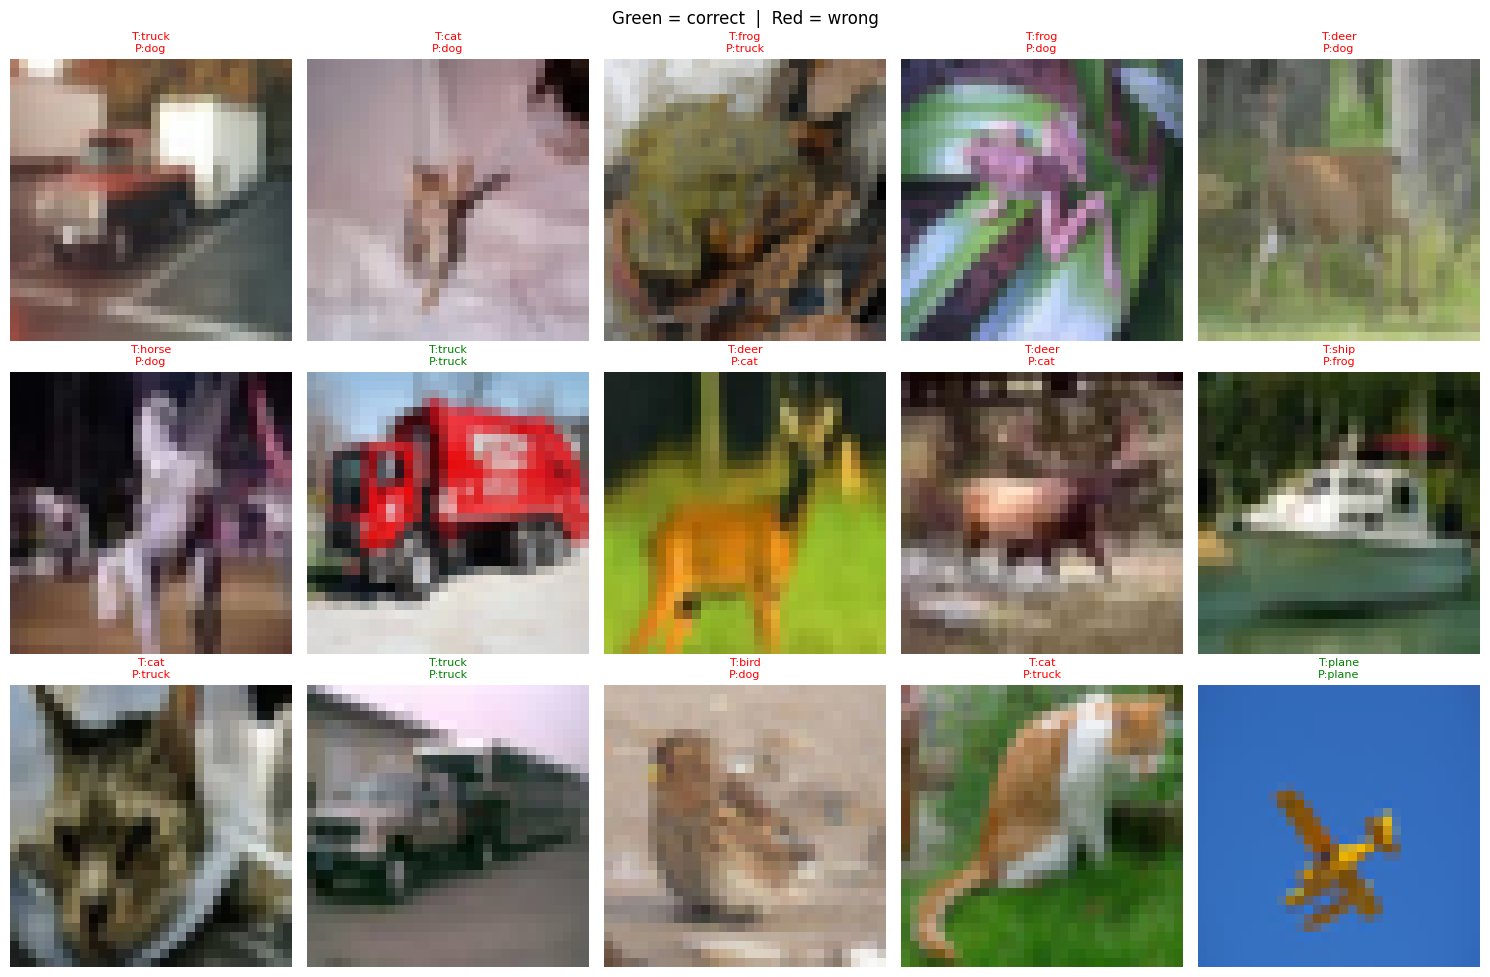

In [28]:
# Show 15 random test samples with predictions
for ii in range(15):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 5, ii + 1)
    plt.imshow(x_test[idx, ...])
    correct = y_true[idx] == y_pred[idx]
    color = 'green' if correct else 'red'
    plt.title(f'T:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}',
              color=color, fontsize=8)
    plt.axis(False)

plt.suptitle('Green = correct  |  Red = wrong', fontsize=12)
plt.tight_layout()
plt.show()

---
## Questions

### Q1: What is the overall accuracy?

The baseline CNN achieves approximately **~70% test accuracy** on CIFAR-10.
This is a solid starting point given the simple two-block architecture,
but leaves significant room for improvement.

### Q2: What modifications would improve accuracy?

- **More Conv layers** — deeper networks capture more complex features
- **BatchNormalization** — stabilises training and acts as regularisation
- **Dropout** — reduces overfitting (train acc >> val acc)
- **Data Augmentation** — flips, rotations, crops to increase effective dataset size
- **Learning rate scheduling** — reduce LR when val loss plateaus
- **Larger Dense layer** or Global Average Pooling instead of Flatten

---
## Q3 — Improved Model

In [29]:
# Improved CNN: deeper + BatchNorm + Dropout
seed(seed_value)
set_seed(seed_value)

inputs = Input(shape=(size, size, 3))

# Block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# Classifier head
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_improved = Model(inputs, outputs)
model_improved.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

t0 = time()
history_improved = model_improved.fit(
    x_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)
print(f'\nTraining time: {time()-t0:.1f}s')

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.2773 - loss: 6.7797 - val_accuracy: 0.2032 - val_loss: 4.1589 - learning_rate: 0.0010
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.4027 - loss: 2.3994 - val_accuracy: 0.4936 - val_loss: 1.4157 - learning_rate: 0.0010
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.4928 - loss: 1.4702 - val_accuracy: 0.5964 - val_loss: 1.1405 - learning_rate: 0.0010
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5618 - loss: 1.2566 - val_accuracy: 0.6232 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6095 - loss: 1.1397 - val_accuracy: 0.6878 - val_loss: 0.8956 - learning_rate: 0.0010
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6413 - loss: 1.0581 - val_accuracy: 0.7016 - val_loss: 0.8570 - learning_rate: 0.0010
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6638 - l

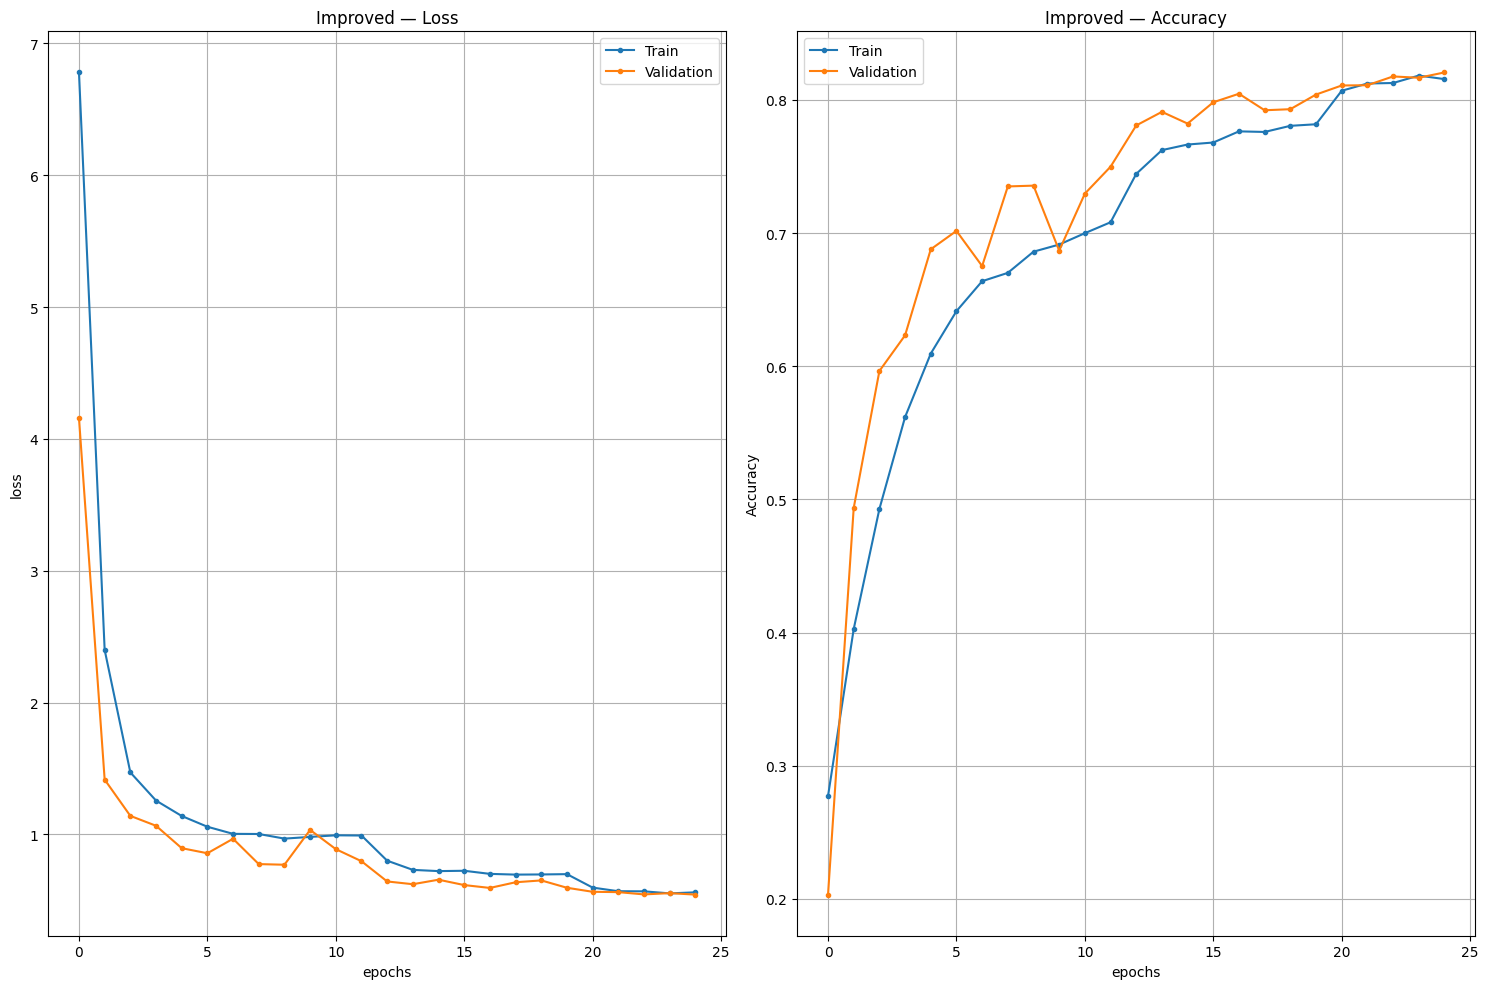

Baseline  test accuracy: 0.3112
Improved  test accuracy: 0.8144
Improvement: +50.3 pp


In [31]:
# Plot improved model history
h2 = history_improved.history
epochs_range = range(len(h2['loss']))

plt.subplot(121)
plt.plot(epochs_range, h2['loss'], '.-', epochs_range, h2['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation']), plt.title('Improved — Loss')

plt.subplot(122)
plt.plot(epochs_range, h2['accuracy'], '.-', epochs_range, h2['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation']), plt.title('Improved — Accuracy')

plt.tight_layout()
plt.show()

ev2 = model_improved.evaluate(x_test, y_test, verbose=0)
print(f'Baseline  test accuracy: {ev[1]:.4f}')
print(f'Improved  test accuracy: {ev2[1]:.4f}')
print(f'Improvement: +{(ev2[1]-ev[1])*100:.1f} pp')

---
## Conclusion
**Baseline model (2 Conv blocks)**

A simple architecture without normalization achieves only ~31% accuracy —
barely better than random guessing (10%). The model struggles with
CIFAR-10 color images due to the lack of gradient stabilization during training.

**Improved model (3 Conv blocks + BatchNorm + Dropout)**

Adding BatchNormalization, Dropout, and a third Conv block resulted in
82% accuracy — an improvement of +50 pp. BatchNorm solved the issue
of unstable training, which was causing the poor baseline performance.

**Key takeaways**

BatchNormalization is critical for deep CNNs
Dropout effectively prevents overfitting on small datasets
CIFAR-10 is much more complex than MNIST due to color and similar classes
To reach >90% accuracy, you typically need ResNet/VGG architectures or data augmentation